## 라이브러리 임포트

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog
import os
from collections import Counter

## 파일 선택 함수

In [13]:
def select_dataset_file():
    """GUI로 npz 파일을 선택"""
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)  # 창을 최상위로
    root.lift()  # 포커스 강제
    root.focus_force()  # 포커스 강제
    
    file_path = filedialog.askopenfilename(
        title="검사할 .npz 파일을 선택하세요",
        filetypes=[("NumPy files", "*.npz"), ("All files", "*.*")],
        initialdir=os.getcwd(),
        parent=root
    )
    
    root.destroy()  # 명시적으로 제거
    return file_path

## 파일 정보 출력 함수

In [14]:
def print_file_info(file_path):
    """파일 기본 정보 출력"""
    file_size = os.path.getsize(file_path)
    file_size_mb = file_size / 1024 / 1024
    
    print("=" * 70)
    print("📁 파일 정보")
    print("=" * 70)
    print(f"파일명: {os.path.basename(file_path)}")
    print(f"경로: {file_path}")
    print(f"크기: {file_size_mb:.2f} MB ({file_size:,} bytes)")
    print()

## 데이터셋 구조 분석 함수

In [15]:
def analyze_dataset_structure(data):
    """데이터셋 구조 및 키 정보 출력"""
    print("=" * 70)
    print("📊 데이터셋 구조")
    print("=" * 70)
    print(f"키 목록: {list(data.keys())}")
    print()
    
    for key in data.keys():
        arr = data[key]
        print(f"[{key}]")
        print(f"  Shape: {arr.shape}")
        print(f"  Dtype: {arr.dtype}")
        print(f"  Size: {arr.size:,} elements")
        print(f"  Memory: {arr.nbytes / 1024 / 1024:.2f} MB")
        print()

## 통계 정보 출력 함수

In [16]:
def print_statistics(data):
    """데이터셋 통계 정보 출력"""
    print("=" * 70)
    print("📈 통계 정보")
    print("=" * 70)
    
    for key in data.keys():
        arr = data[key]
        print(f"[{key}]")
        print(f"  Min: {arr.min()}")
        print(f"  Max: {arr.max()}")
        print(f"  Mean: {arr.mean():.4f}")
        print(f"  Std: {arr.std():.4f}")
        
        # 레이블인 경우 고유값 출력
        if 'label' in key.lower():
            unique_values = np.unique(arr)
            print(f"  Unique values: {unique_values}")
            print(f"  Number of classes: {len(unique_values)}")
        
        print()

## 데이터 미리보기 함수

In [17]:
def preview_data(data, num_samples=5):
    """첫 몇 개 샘플 미리보기 (numpy의 배열 슬라이싱 사용)"""
    print("=" * 70)
    print(f"👀 데이터 미리보기 (처음 {num_samples}개)")
    print("=" * 70)
    
    for key in data.keys():
        arr = data[key]
        print(f"[{key}]")
        
        # 이미지 데이터는 shape만 표시
        if len(arr.shape) >= 3:
            print(f"  처음 {num_samples}개 shape: {arr[:num_samples].shape}")
            print(f"  (이미지 데이터는 아래 시각화 참고)")
        else:
            # 레이블 등은 실제 값 출력
            print(f"  {arr[:num_samples]}")
        print()

## 레이블 분포 시각화 함수

In [18]:
def plot_label_distribution(labels, dataset_name):
    """레이블 분포를 막대 그래프로 시각화"""
    counter = Counter(labels)
    classes = sorted(counter.keys())
    counts = [counter[c] for c in classes]
    
    plt.figure(figsize=(10, 5))
    plt.bar(classes, counts, color='steelblue', alpha=0.7)
    plt.xlabel('Class Label', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.title(f'Label Distribution - {dataset_name}', fontsize=14, fontweight='bold')
    plt.xticks(classes)
    plt.grid(axis='y', alpha=0.3)
    
    # 각 막대 위에 개수 표시
    for i, (c, count) in enumerate(zip(classes, counts)):
        plt.text(c, count, str(count), ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # 통계 출력
    print("\n📊 레이블 분포 통계:")
    for c in classes:
        percentage = (counter[c] / len(labels)) * 100
        print(f"  Class {c}: {counter[c]:,}개 ({percentage:.2f}%)")
    print(f"  총 샘플 수: {len(labels):,}개\n")

## 이미지 샘플 시각화 함수

In [ ]:
def visualize_image_samples(images, labels, num_samples=20):
    """이미지 샘플들을 시각화"""
    # 샘플 개수 조정
    num_samples = min(num_samples, len(images))
    
    # 랜덤하게 샘플 선택
    random_indices = np.random.choice(len(images), size=num_samples, replace=False)
    
    # 그리드 설정
    cols = 5
    rows = (num_samples + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    fig.suptitle('Image Samples (Random)', fontsize=16, fontweight='bold')
    
    # 1차원 배열로 변환 (for문 처리 편의)
    if rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for i in range(len(axes)):
        if i < num_samples:
            idx = random_indices[i]
            img = images[idx]
            
            # 이미지 형식 판단 및 표시
            if len(img.shape) == 2:  # Grayscale
                axes[i].imshow(img, cmap='gray')
            elif len(img.shape) == 3 and img.shape[2] == 3:  # RGB
                axes[i].imshow(img)
            elif len(img.shape) == 3 and img.shape[2] == 1:  # Grayscale with channel
                axes[i].imshow(img.squeeze(), cmap='gray')
            else:
                axes[i].text(0.5, 0.5, f'Shape: {img.shape}', 
                           ha='center', va='center', transform=axes[i].transAxes)
            
            # 레이블 표시
            if labels is not None:
                axes[i].set_title(f'Label: {labels[idx]}', fontsize=10)
            
            axes[i].axis('off')
        else:
            axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

## 메인 검사 함수

In [20]:
def inspect_dataset(file_path=None, num_preview=5, num_visualize=20):
    """
    데이터셋을 전반적으로 검사
    
    Args:
        file_path (str): npz 파일 경로. None이면 GUI로 선택
        num_preview (int): 미리보기할 샘플 개수
        num_visualize (int): 시각화할 이미지 개수
    """
    # 파일 선택
    if file_path is None:
        file_path = select_dataset_file()
    
    if not file_path:
        print("❌ 파일이 선택되지 않았습니다.")
        return
    
    try:
        # 파일 정보 출력
        print_file_info(file_path)
        
        # 데이터 로드
        print("📂 데이터 로드 중...\n")
        data = np.load(file_path)
        
        # 데이터셋 구조 분석
        analyze_dataset_structure(data)
        
        # 통계 정보
        print_statistics(data)
        
        # 데이터 미리보기
        preview_data(data, num_samples=num_preview)
        
        # 이미지와 레이블 추출 (일반적인 키 이름들 시도)
        images = None
        labels = None
        
        # 이미지 키 찾기
        for key in ['train_images', 'images', 'X', 'data']:
            if key in data:
                images = data[key]
                break
        
        # 레이블 키 찾기
        for key in ['train_labels', 'labels', 'y', 'digit_labels']:
            if key in data:
                labels = data[key]
                break
        
        # 레이블 분포 시각화
        if labels is not None:
            dataset_name = os.path.basename(file_path)
            plot_label_distribution(labels, dataset_name)
        
        # 이미지 샘플 시각화
        if images is not None:
            print("=" * 70)
            print(f"🖼️  이미지 시각화 ({num_visualize}개 샘플)")
            print("=" * 70)
            visualize_image_samples(images, labels, num_samples=num_visualize)
        else:
            print("⚠️  이미지 데이터를 찾을 수 없습니다.")
        
        print("\n✅ 검사 완료!")
        
    except Exception as e:
        print(f"\n❌ 오류 발생: {e}")
        raise

## 실행

📁 파일 정보
파일명: mnist_merged_original+full+partial.npz
경로: C:/Users/lota/Documents/SourceCodes/ML_25_2/assets/mnist_merged_original+full+partial.npz
크기: 3.64 MB (3,814,160 bytes)

📂 데이터 로드 중...

📊 데이터셋 구조
키 목록: ['train_images', 'train_labels']

[train_images]
  Shape: (70000, 28, 28, 3)
  Dtype: uint8
  Size: 164,640,000 elements
  Memory: 157.01 MB

[train_labels]
  Shape: (70000,)
  Dtype: int64
  Size: 70,000 elements
  Memory: 0.53 MB

📈 통계 정보
[train_images]
  Min: 0
  Max: 255
  Mean: 106.2436
[train_images]
  Min: 0
  Max: 255
  Mean: 106.2436
  Std: 111.0648

[train_labels]
  Min: 0
  Max: 9
  Mean: 4.4605
  Std: 2.8869
  Unique values: [0 1 2 3 4 5 6 7 8 9]
  Number of classes: 10

👀 데이터 미리보기 (처음 5개)
[train_images]
  처음 5개 shape: (5, 28, 28, 3)
  (이미지 데이터는 아래 시각화 참고)

[train_labels]
  [0 0 0 0 0]

  Std: 111.0648

[train_labels]
  Min: 0
  Max: 9
  Mean: 4.4605
  Std: 2.8869
  Unique values: [0 1 2 3 4 5 6 7 8 9]
  Number of classes: 10

👀 데이터 미리보기 (처음 5개)
[train_images]
  처음 5개 s

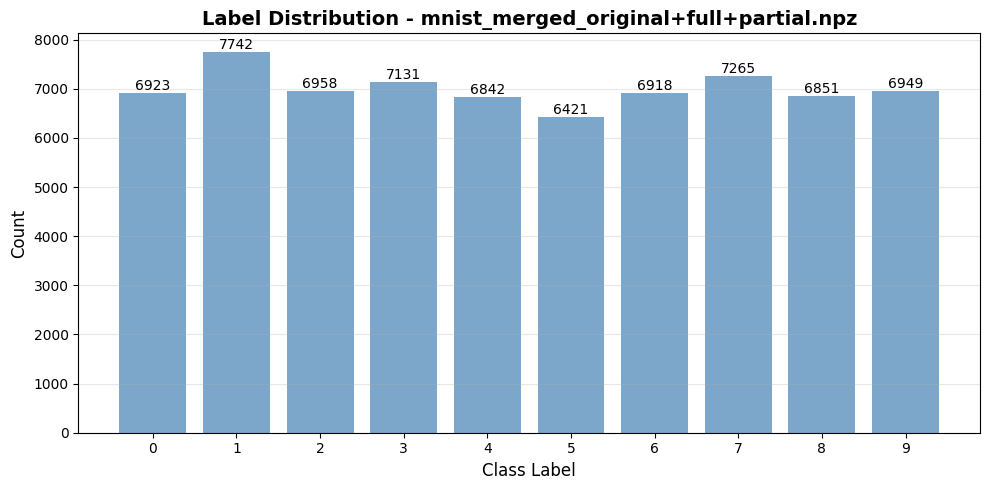


📊 레이블 분포 통계:
  Class 0: 6,923개 (9.89%)
  Class 1: 7,742개 (11.06%)
  Class 2: 6,958개 (9.94%)
  Class 3: 7,131개 (10.19%)
  Class 4: 6,842개 (9.77%)
  Class 5: 6,421개 (9.17%)
  Class 6: 6,918개 (9.88%)
  Class 7: 7,265개 (10.38%)
  Class 8: 6,851개 (9.79%)
  Class 9: 6,949개 (9.93%)
  총 샘플 수: 70,000개

🖼️  이미지 시각화 (20개 샘플)


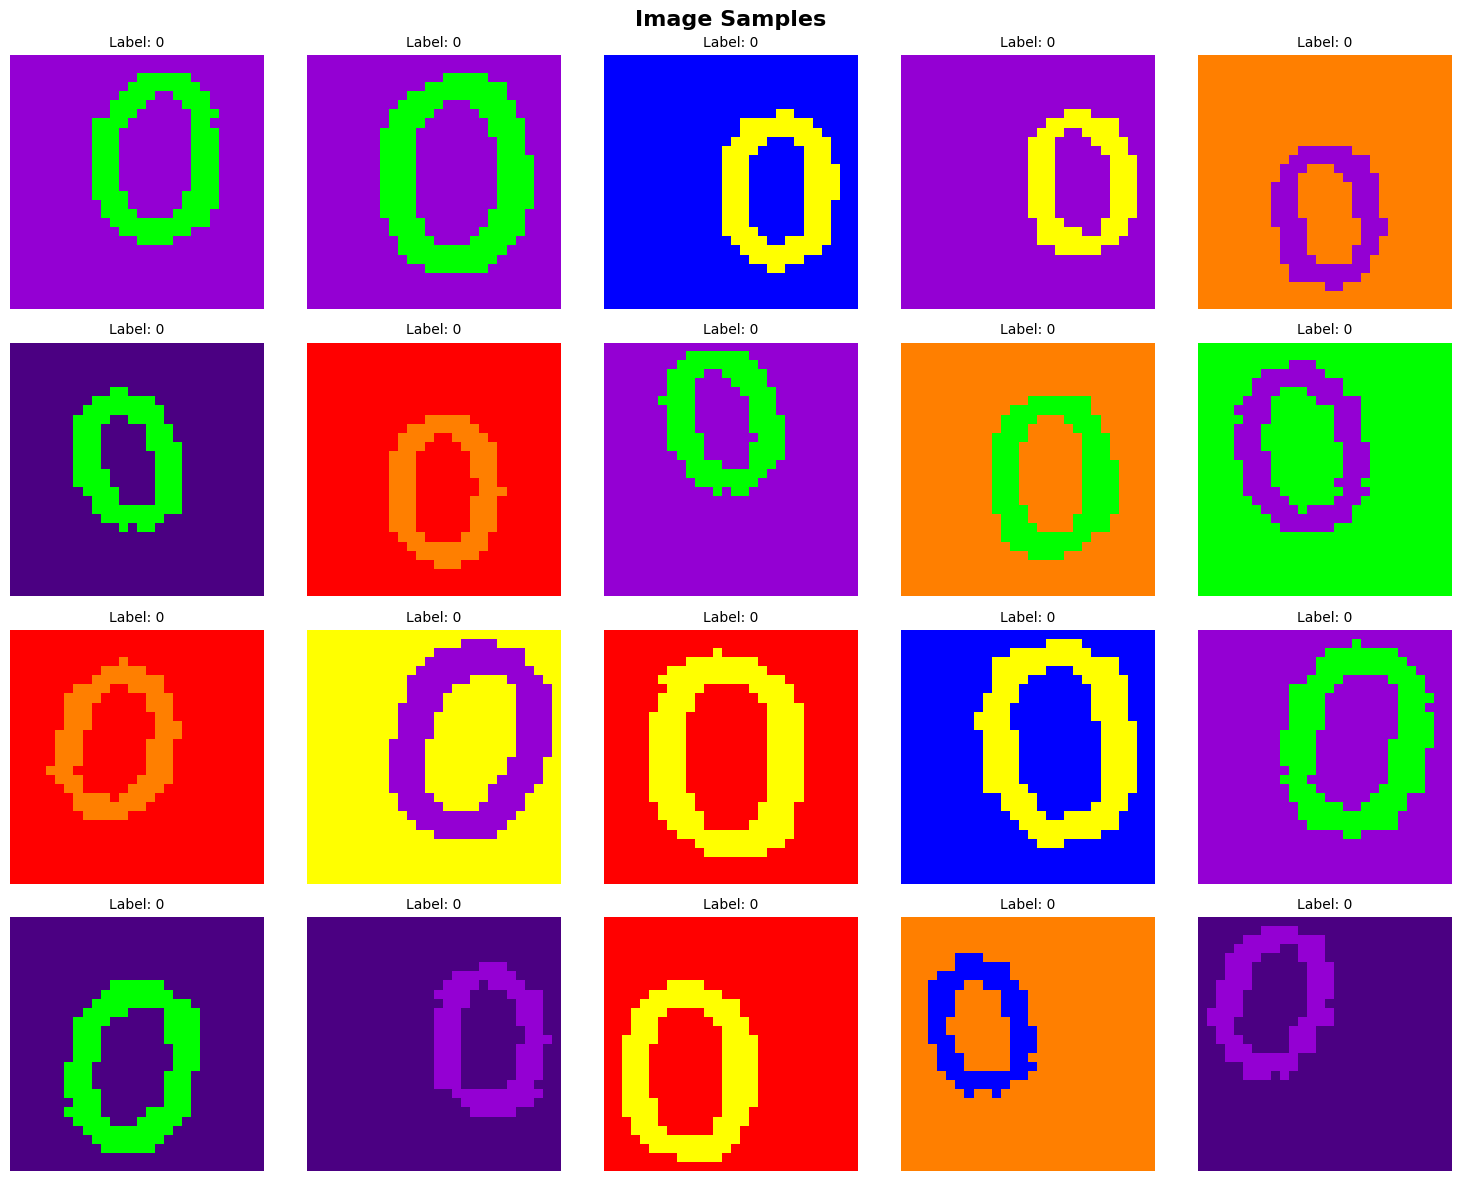


✅ 검사 완료!


In [21]:
# GUI로 파일 선택하여 검사 실행
inspect_dataset(num_preview=5, num_visualize=20)

## 직접 경로 지정하여 실행 (선택사항)

In [22]:
# 파일 경로를 직접 지정하여 실행하려면 아래 주석을 해제하고 실행
# inspect_dataset(
#     file_path='mnist_train.npz',
#     num_preview=5,
#     num_visualize=20
# )